# Email Spam Detection with Machine Learning

## Objective

The objective of this project is to build a machine learning model that classifies SMS messages as Spam or Ham (Not Spam) using Natural Language Processing (NLP). The project includes text preprocessing, feature extraction using TF-IDF, model training, model evaluation, and comparison of multiple classifiers.

## Import Required Libraries

The required libraries are imported for data analysis, visualization, text preprocessing, machine learning, and model evaluation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import nltk

nltk.download('stopwords')

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from wordcloud import WordCloud

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Omkar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Step 1: Load the Dataset

The SMS Spam Collection dataset is loaded into a Pandas DataFrame for further analysis.

In [4]:
df = pd.read_csv(r"C:\Users\Omkar\Downloads\archive (2)\spam.csv", encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## Step 3: Data Cleaning

In this step, unnecessary columns are removed and the remaining columns are renamed to improve readability.

In [10]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Step 4: Dataset Information

This step examines the dataset structure, including the number of rows and columns, data types, missing values, and statistical information.

In [12]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
label      0
message    0
dtype: int64


In [13]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (5572, 2)


In [14]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [15]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
label      0
message    0
dtype: int64


## Step 5: Label Encoding

The target labels are converted into numerical values:
- Ham → 0
- Spam → 1

In [16]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## Step 6: Class Distribution

The distribution of spam and ham messages is visualized to understand whether the dataset is balanced.

In [17]:

print(df['label'].value_counts())

label
0    4825
1     747
Name: count, dtype: int64


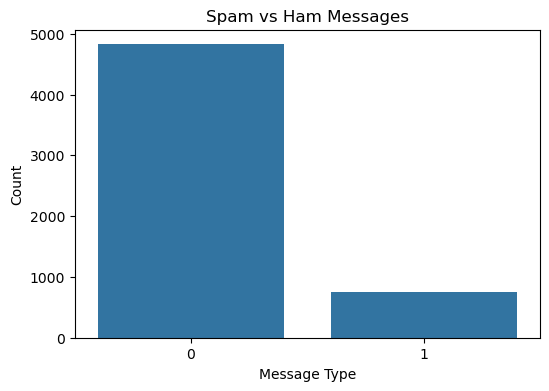

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()

### Observation

The dataset contains more Ham (non-spam) messages than Spam messages. This indicates that the dataset is slightly imbalanced, which is common in real-world email datasets.

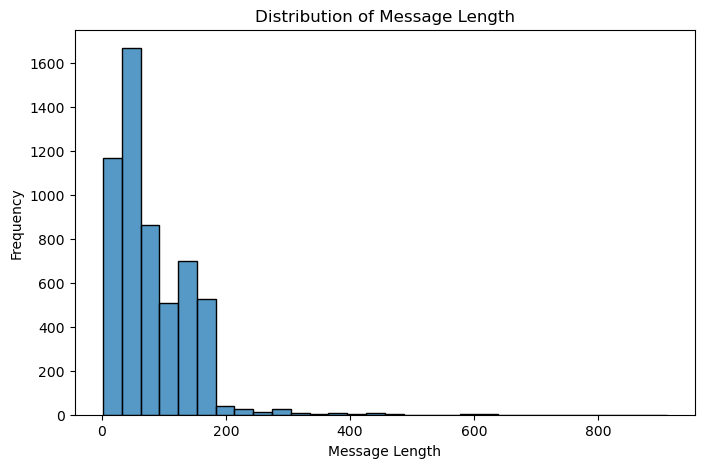

In [19]:
df['message_length'] = df['message'].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df['message_length'], bins=30)
plt.title("Distribution of Message Length")
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.show()

### Observation

Most messages are relatively short. However, spam messages tend to have longer text compared to many normal messages.

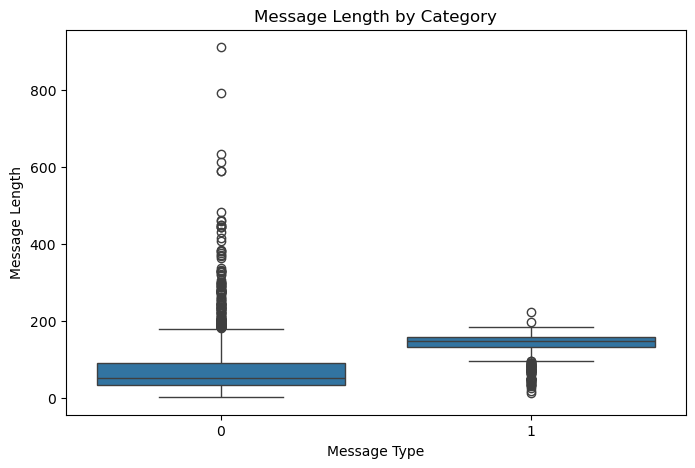

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='message_length', data=df)
plt.title("Message Length by Category")
plt.xlabel("Message Type")
plt.ylabel("Message Length")
plt.show()

### Observation

Spam messages generally have a higher message length than ham messages. The boxplot also shows several outliers representing unusually long messages.

### Observation

The target variable has been converted into numerical format where:
- Ham = 0
- Spam = 1

Machine learning models require numerical target values for training.

In [22]:
X = df['message']
y = df['label']

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

X = tfidf.fit_transform(X)

### Observation

TF-IDF converts text messages into numerical feature vectors by assigning higher importance to informative words while reducing the importance of commonly occurring words.

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Observation

The dataset has been divided into training and testing sets. The training set is used to build the model, while the testing set is used to evaluate its performance on unseen data.

In [27]:

df = pd.read_csv(r"C:\Users\Omkar\Downloads\archive (2)\spam.csv", encoding="latin-1")
# Keep only the required columns
df = df[['v1', 'v2']]

df.columns = ['label', 'message']


df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print(df.head())
print(df['label'].unique())

   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...
[0 1]


In [28]:
X = df['message']
y = df['label']

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')
X = tfidf.fit_transform(X)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Step 8: Train Multinomial Naive Bayes Model

Multinomial Naive Bayes is a widely used algorithm for text classification tasks because it performs efficiently on TF-IDF features.

In [32]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

MultinomialNB()

## Step 9: Model Prediction

Predictions are generated on the test dataset using both trained models.

In [33]:
lr_pred = model.predict(X_test)

nb_pred = nb_model.predict(X_test)

## Step 10: Logistic Regression Evaluation

The Logistic Regression model is evaluated using Accuracy, Precision, Recall, F1-score, Confusion Matrix, and Classification Report.

In [34]:
print("Logistic Regression Results")

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

print("\nClassification Report\n")
print(classification_report(y_test, lr_pred))

Logistic Regression Results
Accuracy : 0.9443946188340807
Precision: 0.9680851063829787
Recall   : 0.6066666666666667
F1 Score : 0.7459016393442623

Classification Report

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       965
           1       0.97      0.61      0.75       150

    accuracy                           0.94      1115
   macro avg       0.96      0.80      0.86      1115
weighted avg       0.95      0.94      0.94      1115



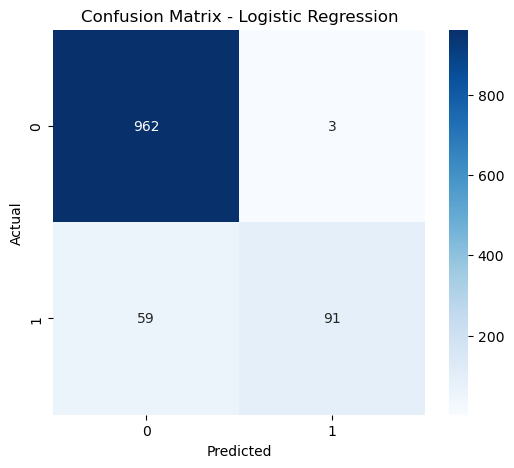

In [35]:
plt.figure(figsize=(6,5))

sns.heatmap(confusion_matrix(y_test, lr_pred),
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation

The confusion matrix shows the number of correctly and incorrectly classified spam and ham messages. Most messages are classified correctly, indicating good model performance.

## Step 11: Multinomial Naive Bayes Evaluation

The Multinomial Naive Bayes model is evaluated using the same performance metrics.

In [36]:
print("Multinomial Naive Bayes Results")

print("Accuracy :", accuracy_score(y_test, nb_pred))
print("Precision:", precision_score(y_test, nb_pred))
print("Recall   :", recall_score(y_test, nb_pred))
print("F1 Score :", f1_score(y_test, nb_pred))

print("\nClassification Report\n")
print(classification_report(y_test, nb_pred))

Multinomial Naive Bayes Results
Accuracy : 0.968609865470852
Precision: 1.0
Recall   : 0.7666666666666667
F1 Score : 0.8679245283018868

Classification Report

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115



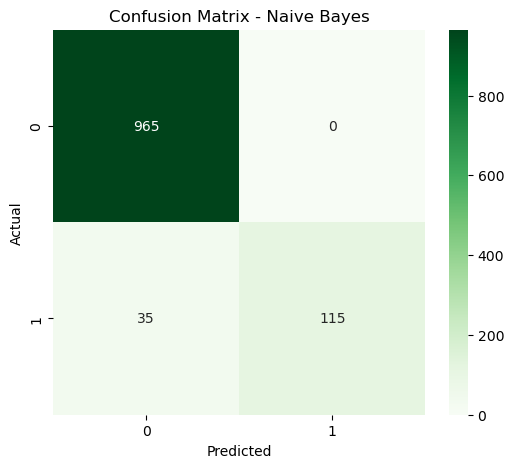

In [37]:
plt.figure(figsize=(6,5))

sns.heatmap(confusion_matrix(y_test, nb_pred),
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [38]:
comparison = pd.DataFrame({
    'Model':['Logistic Regression','Multinomial Naive Bayes'],
    'Accuracy':[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.944395
1,Multinomial Naive Bayes,0.968610


### Observation

The comparison table shows the accuracy of both classification models. The model with the higher accuracy and balanced precision, recall, and F1-score is selected as the best-performing model.

## Step 12: Best Performing Model

Based on the evaluation results, the Multinomial Naive Bayes model achieved the highest accuracy of **96.86%**, outperforming the Logistic Regression model (94.44%). Therefore, Multinomial Naive Bayes is selected as the best-performing model for this spam detection task.

## Step 13: TF-IDF Explanation

TF-IDF (Term Frequency–Inverse Document Frequency) is a text feature extraction technique used to convert textual data into numerical values.

- **Term Frequency (TF):** Measures how frequently a word appears in a document.
- **Inverse Document Frequency (IDF):** Reduces the importance of words that appear very frequently across all documents.

TF-IDF gives higher weights to important words and lower weights to common words, making it suitable for text classification tasks such as spam detection.

## Step 14: Importance of Recall in Spam Detection

Recall is an important evaluation metric for spam detection because it measures how many actual spam messages are correctly identified by the model.

A higher recall reduces the chances of spam messages being classified as normal (ham), helping users avoid unwanted or potentially harmful messages.

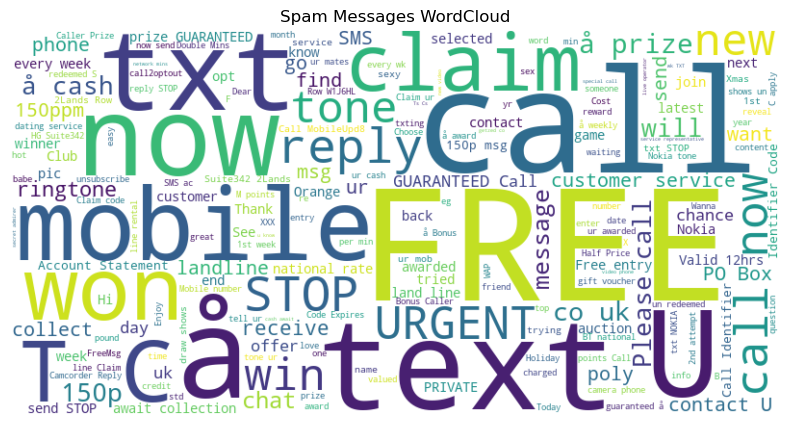

In [39]:
spam_words = ' '.join(df[df['label']==1]['message'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(spam_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Spam Messages WordCloud")
plt.show()

### Observation

The WordCloud highlights the most frequently occurring words in spam messages. Words related to prizes, free offers, and rewards appear more prominently, reflecting common spam message patterns.

# Conclusion

An Email Spam Detection model was successfully developed using Natural Language Processing (NLP) techniques and machine learning algorithms.

The SMS messages were preprocessed, converted into numerical features using TF-IDF Vectorization, and classified using Logistic Regression and Multinomial Naive Bayes.

Among the two models, **Multinomial Naive Bayes** achieved the highest accuracy of **96.86%**, making it the best-performing model for this dataset. The project demonstrates how machine learning can effectively identify spam messages with high accuracy and reliability.